In [46]:
import pandas as pd

## load dataset

In [48]:
df=pd.read_csv(r"C:\Users\Admin\Desktop\student_analysis.csv")

In [50]:
df

,Student_ID,Sleep_Hours,Study_Hours,Mobile_Using_Hours,Mood,Marks
0,1,7.0,3.0,5,Stressed,60
1,2,9.0,4.0,2,Happy,85
2,3,6.0,2.0,6,Anxiety,50
3,4,10.0,5.0,3,Happy,78
4,5,5.0,1.0,1,Happy,95
5,6,6.5,2.0,7,Anxiety,45
6,7,4.0,3.0,4,Stressed,58
7,8,9.0,3.0,3,Stressed,88
8,9,8.0,4.0,2,Happy,75
9,10,8.0,1.0,5,Anxiety,55


In [52]:
df.head()

,Student_ID,Sleep_Hours,Study_Hours,Mobile_Using_Hours,Mood,Marks
0,1,7.0,3.0,5,Stressed,60
1,2,9.0,4.0,2,Happy,85
2,3,6.0,2.0,6,Anxiety,50
3,4,10.0,5.0,3,Happy,78
4,5,5.0,1.0,1,Happy,95


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          15 non-null     int64  
 1   Sleep_Hours         15 non-null     float64
 2   Study_Hours         15 non-null     float64
 3   Mobile_Using_Hours  15 non-null     int64  
 4   Mood                15 non-null     object 
 5   Marks               15 non-null     int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 852.0+ bytes


In [56]:
df.describe()

,Student_ID,Sleep_Hours,Study_Hours,Mobile_Using_Hours,Marks
count,15.000000,15.000000,15.000000,15.000000,15.00000
mean,8.000000,7.633333,3.066667,4.266667,66.60000
std,4.472136,2.108373,1.293758,2.186539,17.59383
min,1.000000,4.000000,1.000000,1.000000,45.00000
25%,4.500000,6.250000,2.000000,2.500000,52.50000
50%,8.000000,7.000000,3.000000,4.000000,60.00000
75%,11.500000,9.000000,4.000000,6.000000,81.50000
max,15.000000,12.000000,5.000000,8.000000,95.00000


In [58]:
df['Marks'].mean()

66.6

In [44]:
df.groupby('Mood')['Marks'].mean()

Mood
            Happy       85.00
            Stressed    60.00
Anxiety                 51.00
Happy                   84.50
Stressed                65.25
Name: Marks, dtype: float64

In [60]:
top_students=df.sort_values(by='Marks',ascending=False).head(5)
print('top 5 students',top_students)av

top 5 students     Student_ID  Sleep_Hours  Study_Hours  Mobile_Using_Hours  \
4            5          5.0          1.0                   1   
11          12         12.0          5.0                   2   
7            8          9.0          3.0                   3   
1            2          9.0          4.0                   2   
3            4         10.0          5.0                   3   

                 Mood  Marks  
4               Happy     95  
11              Happy     90  
7            Stressed     88  
1               Happy     85  
3               Happy     78  


In [64]:
low_students=df.sort_values(by='Marks').head(5)
print('low performing students',low_students)

low performing students     Student_ID  Sleep_Hours  Study_Hours  Mobile_Using_Hours      Mood  Marks
5            6          6.5          2.0                   7   Anxiety     45
10          11         10.0          2.0                   6   Anxiety     45
14          15          6.0          3.0                   7  Stressed     45
2            3          6.0          2.0                   6   Anxiety     50
9           10          8.0          1.0                   5   Anxiety     55


## high sleep students

In [71]:
high_sleep=df[df['Sleep_Hours']>=8]['Marks'].mean()
low_sleep=df[df['Sleep_Hours']<=5]['Marks'].mean()
print('average marks(high sleep>=8hrs):',high_sleep)
print('average marks(low sleep>=5hrs):',low_sleep)

average marks(high sleep>=8hrs): 73.71428571428571
average marks(low sleep>=5hrs): 76.5


## high mobile usage

In [74]:
high_mobile=df[df['Mobile_Using_Hours']>=6]['Marks'].mean()
low_mobile=df[df['Mobile_Using_Hours']<=3]['Marks'].mean()
print('average marks(high smobile usage >= 6hrs):',high_mobile)
print('average marks(low mobile >= 3hrs):',low_mobile)

average marks(high smobile usage >= 6hrs): 49.0
average marks(low mobile >= 3hrs): 83.0


# box plot

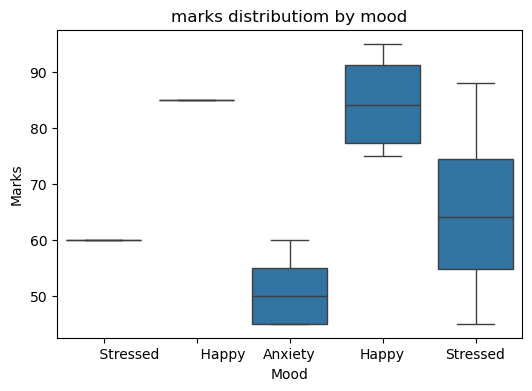

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
sns.boxplot(x='Mood',y='Marks',data=df)
plt.title('marks distributiom by mood')
plt.show()

## regression plot

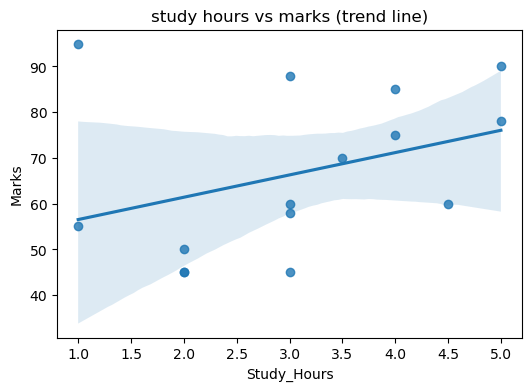

In [82]:
plt.figure(figsize=(6,4))
sns.regplot(x='Study_Hours',y='Marks',data=df)
plt.title('study hours vs marks (trend line)')
plt.show()

## pair plot

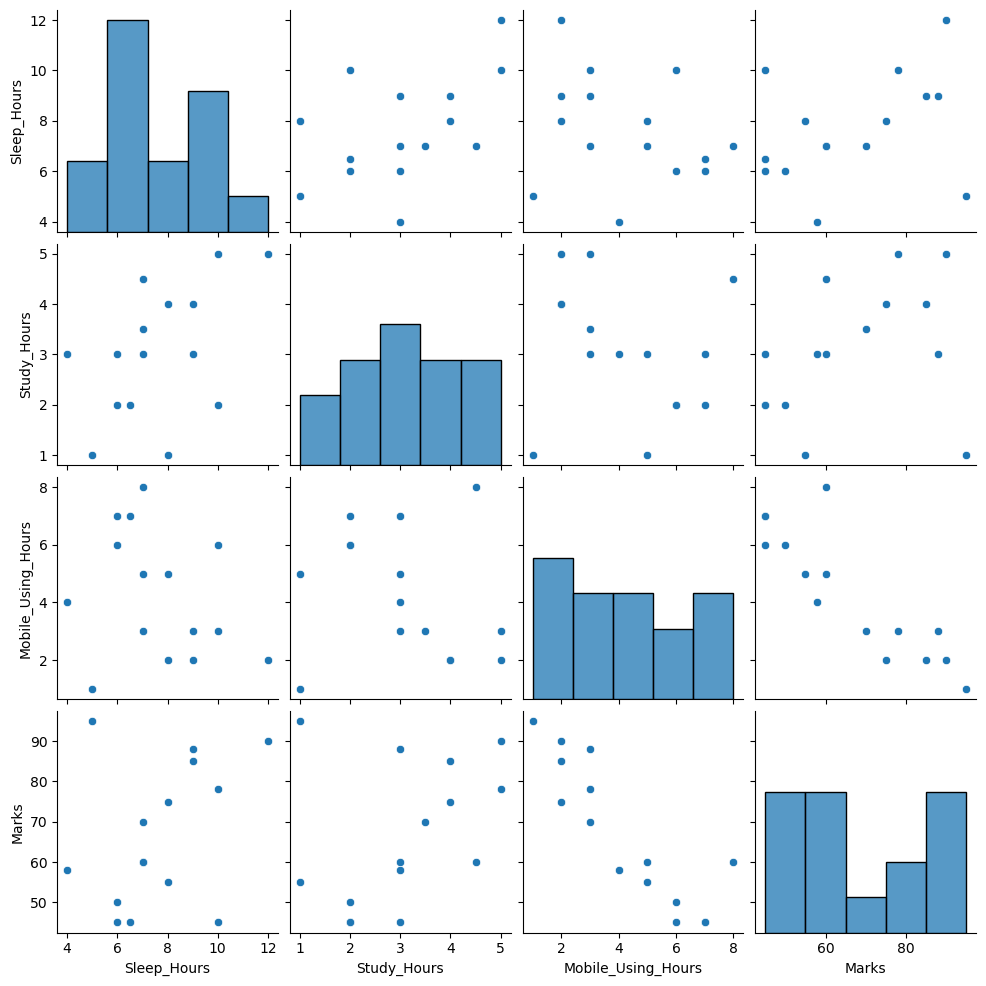

In [85]:
sns.pairplot(df[['Sleep_Hours','Study_Hours','Mobile_Using_Hours','Marks']])
plt.show()

## predicting marks

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [92]:
X=df[['Sleep_Hours','Study_Hours','Mobile_Using_Hours']]
Y=df['Marks']

In [112]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [114]:
model =LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [116]:
score = model.score(X_test,Y_test)
print('Model Accuracy:',score)

Model Accuracy: 0.9679104639596815
